# A. IMPORT LIBRARY

In [1]:
# Basic
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Optional
from xgboost import XGBRegressor

# B. EXPLORATORY DATA ANALYSIS

In [2]:
df = pd.read_csv("train.csv")

print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

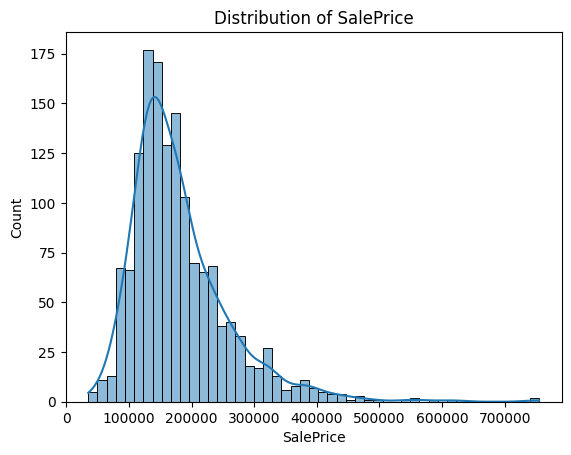

In [3]:
print(df.info())
print(df.describe())

# distribusi target
sns.histplot(df['SalePrice'], kde=True)
plt.title("Distribution of SalePrice")
plt.show()

# C. DATA PREPROCESSING

## Feature Engineering

In [4]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

df['TotalBath'] = (
    df['FullBath'] +
    0.5 * df['HalfBath'] +
    df['BsmtFullBath'] +
    0.5 * df['BsmtHalfBath']
)

# lebih aman daripada total rooms
df['BedroomRatio'] = df['BedroomAbvGr'] / (df['TotRmsAbvGrd'] + 1)

## Feature Dropping

In [5]:
drop_cols = [
    'Id',

    # sudah digabung ke TotalSF
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',

    # sudah digabung ke TotalBath
    'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',

    # sudah jadi age
    'YearBuilt', 'YearRemodAdd'
]

df = df.drop(columns=drop_cols)

## Split Data

In [8]:
X = df.drop('SalePrice', axis=1)
y = np.log1p(df['SalePrice'])  # log transform

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Pisahkan Kolom

In [9]:
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object']).columns

## Preprocessing Pipeline

In [10]:
# Numerical
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# D. DATA MODELLING

## 1. Linear Regression

In [11]:
lr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

## 2. Random Forest

In [12]:
rf_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

## 3. XGBoost

In [13]:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(random_state=42))
])

## 4. Training Model

In [14]:
lr_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'LowQualFinSF',
       'GrLivArea', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRms...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

# E. MODEL EVALUATION

In [24]:
def evaluate_model(model, X_train, y_train, X_test, y_test, name):

    # PREDIKSI
    y_pred_test = model.predict(X_test)
    y_pred_train = model.predict(X_train)

    # BALIK KE SKALA ASLI
    y_test_real = np.expm1(y_test)
    y_train_real = np.expm1(y_train)

    y_pred_test_real = np.expm1(y_pred_test)
    y_pred_train_real = np.expm1(y_pred_train)

    # METRICS STANDARD (TEST)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
    mae = mean_absolute_error(y_test_real, y_pred_test_real)
    r2 = r2_score(y_test_real, y_pred_test_real)

    # MAPE
    mape_train = np.mean(np.abs((y_train_real - y_pred_train_real) / y_train_real)) * 100
    mape_test = np.mean(np.abs((y_test_real - y_pred_test_real) / y_test_real)) * 100

    # KONSISTENSI
    consistency_gap = abs(mape_train - mape_test)

    # GET STATUS
    if consistency_gap < 2:
        status = "Sangat stabil ✅"
    elif consistency_gap < 5:
        status = "Cukup stabil ⚠️"
    else:
        status = "Overfitting ❌"

    # PRINT HASIL
    print(f"\nModel: {name}")
    print("=== TEST METRICS ===")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAE  : {mae:.2f}")
    print(f"R2   : {r2:.4f}")

    print("\n=== MAPE ===")
    print(f"Train MAPE : {mape_train:.2f}%")
    print(f"Test MAPE  : {mape_test:.2f}%")

    print("\n=== KONSISTENSI ===")
    print(f"Gap (Train vs Test) : {consistency_gap:.2f}%")
    print(f"Status: {status}")

    return {
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Train MAPE': mape_train,
        'Test MAPE': mape_test,
        'Consistency Gap': consistency_gap,
        'Status': status
    }


In [17]:
evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test, "Linear Regression")
evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, "Random Forest")
evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, "XGBoost")


Model: Linear Regression
=== TEST METRICS ===
RMSE : 23224.31
MAE  : 15104.47
R2   : 0.9297

=== MAPE ===
Train MAPE : 6.38%
Test MAPE  : 9.20%

=== KONSISTENSI ===
Gap (Train vs Test) : 2.82%
Status: Cukup stabil ⚠️

Model: Random Forest
=== TEST METRICS ===
RMSE : 30739.51
MAE  : 17276.95
R2   : 0.8768

=== MAPE ===
Train MAPE : 3.54%
Test MAPE  : 10.11%

=== KONSISTENSI ===
Gap (Train vs Test) : 6.57%
Status: Overfitting ❌

Model: XGBoost
=== TEST METRICS ===
RMSE : 27086.95
MAE  : 17321.68
R2   : 0.9043

=== MAPE ===
Train MAPE : 0.53%
Test MAPE  : 10.57%

=== KONSISTENSI ===
Gap (Train vs Test) : 10.04%
Status: Overfitting ❌


# F. HYPERPARAMETER TUNING

## Parameter Tuning

## Random Forest Tuning

In [18]:
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 20, None]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best Params RF:", grid_rf.best_params_)

Best Params RF: {'model__max_depth': None, 'model__n_estimators': 200}


## XGBoost

In [19]:
param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best Params XGB:", grid_xgb.best_params_)

Best Params XGB: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


# G. EVALUATE BEST MODEL

In [26]:
eresults = []

# Random Forest
res_rf = evaluate_model(best_rf, X_train, y_train, X_test, y_test, "Tuned Random Forest")
eresults.append(res_rf)

# XGBoost
res_xgb = evaluate_model(best_xgb, X_train, y_train, X_test, y_test, "Tuned XGBoost")
eresults.append(res_xgb)

# (Optional) Linear Regression
res_lr = evaluate_model(lr_pipeline, X_train, y_train, X_test, y_test, "Linear Regression")
eresults.append(res_lr)


Model: Tuned Random Forest
=== TEST METRICS ===
RMSE : 30523.53
MAE  : 17306.38
R2   : 0.8785

=== MAPE ===
Train MAPE : 3.51%
Test MAPE  : 10.12%

=== KONSISTENSI ===
Gap (Train vs Test) : 6.61%
Status: Overfitting ❌

Model: Tuned XGBoost
=== TEST METRICS ===
RMSE : 27185.47
MAE  : 15822.21
R2   : 0.9036

=== MAPE ===
Train MAPE : 4.69%
Test MAPE  : 9.14%

=== KONSISTENSI ===
Gap (Train vs Test) : 4.45%
Status: Cukup stabil ⚠️

Model: Linear Regression
=== TEST METRICS ===
RMSE : 23224.31
MAE  : 15104.47
R2   : 0.9297

=== MAPE ===
Train MAPE : 6.38%
Test MAPE  : 9.20%

=== KONSISTENSI ===
Gap (Train vs Test) : 2.82%
Status: Cukup stabil ⚠️


# H. CROSS VALIDATION

In [27]:
def run_cv(model, X_train, y_train, name):
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    rmse = -scores  # ubah ke positif

    print(f"\n==============================")
    print(f"Model: {name}")
    print(f"==============================")

    print("RMSE per fold :", np.round(rmse, 2))
    print("Mean RMSE     :", round(rmse.mean(), 2))
    print("Std RMSE      :", round(rmse.std(), 2))

    # interpretasi sederhana
    if rmse.std() < 2000:
        print("Status: Stabil ✅")
    else:
        print("Status: Kurang stabil ⚠️")

    return {
        "Model": name,
        "CV_RMSE_Mean": rmse.mean(),
        "CV_RMSE_Std": rmse.std()
    }


# RUN CV UNTUK SEMUA MODEL

results_cv = []

results_cv.append(run_cv(lr_pipeline, X_train, y_train, "Linear Regression"))
results_cv.append(run_cv(best_rf, X_train, y_train, "Random Forest"))
results_cv.append(run_cv(best_xgb, X_train, y_train, "XGBoost"))


# TABEL PERBANDINGAN

results_cv_df = pd.DataFrame(results_cv)
results_cv_df = results_cv_df.sort_values(by='CV_RMSE_Mean')

print("\n===== CV MODEL COMPARISON =====")
display(results_cv_df)


Model: Linear Regression
RMSE per fold : [0.14 0.17 0.16 0.17 0.16]
Mean RMSE     : 0.16
Std RMSE      : 0.01
Status: Stabil ✅

Model: Random Forest
RMSE per fold : [0.13 0.16 0.17 0.13 0.12]
Mean RMSE     : 0.14
Std RMSE      : 0.02
Status: Stabil ✅

Model: XGBoost
RMSE per fold : [0.12 0.14 0.14 0.13 0.11]
Mean RMSE     : 0.13
Std RMSE      : 0.01
Status: Stabil ✅

===== CV MODEL COMPARISON =====


,Model,CV_RMSE_Mean,CV_RMSE_Std
2,XGBoost,0.126875,0.012227
1,Random Forest,0.141687,0.018958
0,Linear Regression,0.158907,0.011885


# I. FEATURE IMPORTANCE

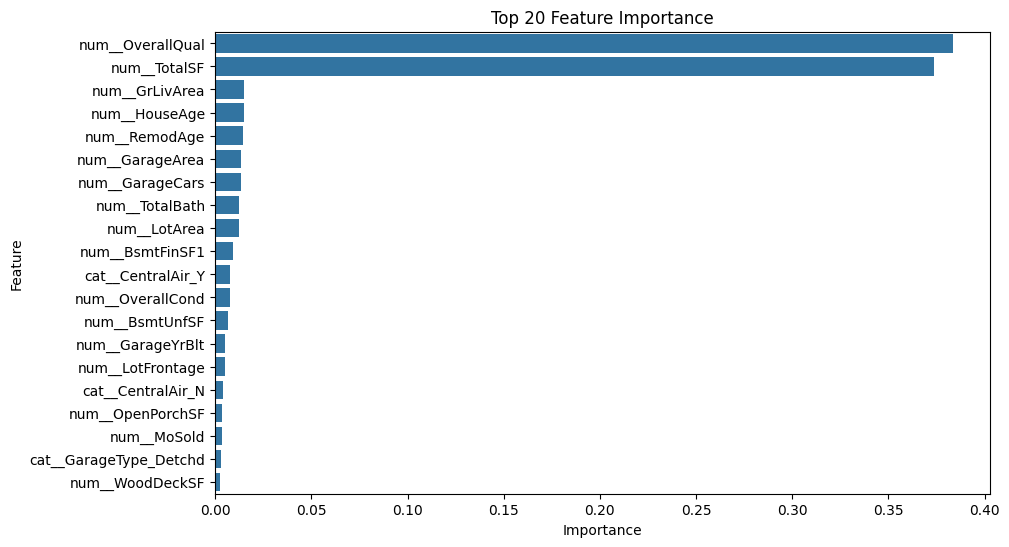

In [28]:
# ambil feature names setelah preprocessing
feature_names = best_rf.named_steps['preprocessing'].get_feature_names_out()

importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# plot top 20
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(20))
plt.title("Top 20 Feature Importance")
plt.show()

# J. ADDITIONAL TEST

In [29]:
def get_test_metrics(model, X_train, y_train, X_test, y_test):
    # prediksi
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # balik ke skala asli
    y_train_real = np.expm1(y_train)
    y_test_real = np.expm1(y_test)

    y_pred_train_real = np.expm1(y_pred_train)
    y_pred_test_real = np.expm1(y_pred_test)

    # metrics test
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_test_real))
    mae = mean_absolute_error(y_test_real, y_pred_test_real)
    r2 = r2_score(y_test_real, y_pred_test_real)

    # MAPE
    mape_train = np.mean(np.abs((y_train_real - y_pred_train_real) / y_train_real)) * 100
    mape_test = np.mean(np.abs((y_test_real - y_pred_test_real) / y_test_real)) * 100

    # gap (konsistensi)
    gap = abs(mape_train - mape_test)

    return rmse, mae, r2, mape_test, gap

In [32]:
models = {
    "Linear Regression": lr_pipeline,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():

    # CV
    cv_results = run_cv(model, X_train, y_train, name)
    cv_mean = cv_results['CV_RMSE_Mean']
    cv_std = cv_results['CV_RMSE_Std']

    # Test + MAPE
    rmse, mae, r2, mape, gap = get_test_metrics(
        model, X_train, y_train, X_test, y_test
    )

    results.append({
        "Model": name,
        "CV_RMSE_Mean": cv_mean,
        "CV_RMSE_Std": cv_std,
        "Test_RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE (%)": mape,
        "Consistency_Gap": gap
    })

results_df = pd.DataFrame(results)

# sorting berdasarkan performa utama
results_df = results_df.sort_values(by="Test_RMSE")

display(results_df)


Model: Linear Regression
RMSE per fold : [0.14 0.17 0.16 0.17 0.16]
Mean RMSE     : 0.16
Std RMSE      : 0.01
Status: Stabil ✅

Model: Random Forest
RMSE per fold : [0.13 0.16 0.17 0.13 0.12]
Mean RMSE     : 0.14
Std RMSE      : 0.02
Status: Stabil ✅

Model: XGBoost
RMSE per fold : [0.12 0.14 0.14 0.13 0.11]
Mean RMSE     : 0.13
Std RMSE      : 0.01
Status: Stabil ✅


,Model,CV_RMSE_Mean,CV_RMSE_Std,Test_RMSE,MAE,R2,MAPE (%),Consistency_Gap
0,Linear Regression,0.158907,0.011885,23224.310244,15104.474894,0.929681,9.199322,2.820092
2,XGBoost,0.126875,0.012227,27185.474381,15822.208423,0.903648,9.139886,4.451794
1,Random Forest,0.141687,0.018958,30523.527126,17306.379048,0.878534,10.117413,6.609310
